# Amazon E-Commerce Dataset Generator  
### Generates 129,000+ realistic order records for MSc portfolio project



In [4]:
"""
Amazon E-Commerce Dataset Generator
Generates 129,000+ realistic order records for MSc portfolio project
"""

#Creating a Dataset 

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

N = 129000

# Date range: Jan 2022 - Dec 2024
start_date = datetime(2022, 1, 1)
end_date = datetime(2024, 12, 31)
date_range = (end_date - start_date).days

# Generate base dates with seasonality
def generate_dates(n):
    dates = []
    for _ in range(n):
        d = start_date + timedelta(days=random.randint(0, date_range))
        # Boost weekends
        if random.random() < 0.15:
            # Push to weekend
            offset = (5 - d.weekday()) % 7
            d = d + timedelta(days=offset)
        # Boost November-December (holiday season)
        if d.month in [11, 12] and random.random() < 0.3:
            pass  # keep
        dates.append(d)
    return sorted(dates)

dates = generate_dates(N)

# Categories
categories = ['Set', 'Kurta', 'Western Dress', 'Top', 'Ethnic Dress',
              'Blouse', 'Bottom', 'Saree', 'Dupatta', 'Lehenga']
cat_weights = [0.22, 0.18, 0.15, 0.14, 0.10, 0.07, 0.05, 0.04, 0.03, 0.02]

# Sizes
sizes = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', 'Free']
size_weights = [0.05, 0.15, 0.25, 0.25, 0.15, 0.08, 0.04, 0.03]

# Colors
colors = ['Black', 'White', 'Navy', 'Red', 'Pink', 'Green', 'Yellow',
          'Blue', 'Orange', 'Purple', 'Beige', 'Multicolor']

# States
states = ['Maharashtra', 'Karnataka', 'Delhi', 'Tamil Nadu', 'Telangana',
          'Uttar Pradesh', 'Gujarat', 'West Bengal', 'Rajasthan', 'Kerala',
          'Punjab', 'Haryana', 'Madhya Pradesh', 'Bihar', 'Odisha']
state_weights = [0.15, 0.12, 0.12, 0.10, 0.09, 0.08, 0.07, 0.07,
                 0.05, 0.05, 0.04, 0.03, 0.01, 0.01, 0.01]

# Fulfilment & channels
fulfilment = ['Amazon', 'Merchant']
channels = ['Amazon.in', 'Non-Amazon']
ship_services = ['Expedited', 'Standard', 'Same Day']
statuses = ['Shipped', 'Delivered to Buyer', 'Cancelled', 'Pending',
            'Returned', 'Shipped - Returned to Seller']
status_weights = [0.40, 0.38, 0.10, 0.05, 0.04, 0.03]

# B2B flag
b2b_probs = [0.90, 0.10]  # 90% B2C

# Promotions — higher in Nov/Dec, Prime Day (Jul), Republic Day (Jan 26)
def is_promotion(dt):
    if dt.month in [11, 12]:
        return random.random() < 0.45
    if dt.month == 7 and 10 <= dt.day <= 15:  # Prime Day
        return random.random() < 0.60
    if dt.month == 1 and 20 <= dt.day <= 28:  # Republic Day Sale
        return random.random() < 0.50
    return random.random() < 0.15

# Price per category (base ₹)
base_prices = {
    'Set': 899, 'Kurta': 549, 'Western Dress': 799, 'Top': 399,
    'Ethnic Dress': 699, 'Blouse': 299, 'Bottom': 349, 'Saree': 999,
    'Dupatta': 249, 'Lehenga': 1499
}

print("Generating dataset...")
rows = []
order_id_counter = 100000

for i, dt in enumerate(dates):
    cat = np.random.choice(categories, p=cat_weights)
    size = np.random.choice(sizes, p=size_weights)
    color = random.choice(colors)
    state = np.random.choice(states, p=state_weights)
    promo = is_promotion(dt)
    qty = np.random.choice([1, 2, 3, 4], p=[0.70, 0.20, 0.07, 0.03])

    base = base_prices[cat]
    # Weekend boost
    weekend = dt.weekday() >= 5
    # Holiday season boost
    holiday = dt.month in [11, 12]

    # Price with noise
    price = base * np.random.uniform(0.85, 1.25)
    if promo:
        price *= np.random.uniform(0.60, 0.85)  # discount
    if holiday:
        price *= 1.05

    amount = round(price * qty, 2)

    status = np.random.choice(statuses, p=status_weights)
    fulfil = np.random.choice(fulfilment, p=[0.75, 0.25])
    channel = 'Amazon.in' if fulfil == 'Amazon' else np.random.choice(channels)
    ship = np.random.choice(ship_services, p=[0.50, 0.40, 0.10])
    b2b = np.random.choice([True, False], p=b2b_probs)

    order_id = f"405-{order_id_counter}-{random.randint(1000000,9999999)}"
    asin = f"B0{random.randint(10,99)}{random.choice('ABCDEFGHIJKLMNOPQRSTUVWXYZ')}{random.randint(10000,99999)}"
    sku = f"{cat[:3].upper()}-{color[:3].upper()}-{size}-{random.randint(100,999)}"

    rows.append({
        'Order ID': order_id,
        'Date': dt.strftime('%Y-%m-%d'),
        'Order Date': dt.strftime('%d-%m-%Y'),
        'Month': dt.strftime('%B'),
        'Year': dt.year,
        'Quarter': f"Q{(dt.month-1)//3+1}",
        'Week': dt.isocalendar()[1],
        'Day of Week': dt.strftime('%A'),
        'Is Weekend': weekend,
        'Status': status,
        'Fulfilment': fulfil,
        'Sales Channel': channel,
        'ship-service-level': ship,
        'Style': f"{cat}-Style-{random.randint(1,50):02d}",
        'SKU': sku,
        'Category': cat,
        'Size': size,
        'ASIN': asin,
        'Courier Status': 'Shipped' if status not in ['Cancelled', 'Pending'] else status,
        'Qty': qty,
        'currency': 'INR',
        'Amount': amount,
        'ship-city': state + ' City',
        'ship-state': state,
        'ship-postal-code': random.randint(100000, 999999),
        'ship-country': 'IN',
        'promotion-ids': f"Amazon FreeShipping|IN Core Free Shipping" if promo else '',
        'Is_Promotion': int(promo),
        'B2B': b2b,
        'fulfilled-by': 'Easy Ship' if fulfil == 'Amazon' else 'Merchant'
    })

    order_id_counter += 1
    if i % 20000 == 0:
        print(f"  Generated {i:,} records...")

df = pd.DataFrame(rows)
df.to_csv('amazon_sales_data.csv', index=False)
print(f"\nDataset saved: {len(df):,} rows x {len(df.columns)} columns")
print(df.dtypes)
print("\nSample:")
print(df.head(3))


Generating dataset...
  Generated 0 records...
  Generated 20,000 records...
  Generated 40,000 records...
  Generated 60,000 records...
  Generated 80,000 records...
  Generated 100,000 records...
  Generated 120,000 records...

Dataset saved: 129,000 rows x 30 columns
Order ID               object
Date                   object
Order Date             object
Month                  object
Year                    int64
Quarter                object
Week                    int64
Day of Week            object
Is Weekend               bool
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int32
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-post

In [14]:
df.head()

,Order ID,Date,Order Date,Month,Year,Quarter,Week,Day of Week,Is Weekend,Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,Is_Promotion,B2B,fulfilled-by
0,405-100000-6912135,2022-01-01,01-01-2022,January,2022,Q1,52,Saturday,True,Shipped,...,INR,500.91,West Bengal City,West Bengal,632664,IN,,0,True,Easy Ship
1,405-100001-1748949,2022-01-01,01-01-2022,January,2022,Q1,52,Saturday,True,Shipped,...,INR,843.64,Haryana City,Haryana,665320,IN,Amazon FreeShipping|IN Core Free Shipping,1,True,Easy Ship
2,405-100002-3178930,2022-01-01,01-01-2022,January,2022,Q1,52,Saturday,True,Cancelled,...,INR,390.64,Maharashtra City,Maharashtra,858998,IN,Amazon FreeShipping|IN Core Free Shipping,1,True,Easy Ship
3,405-100003-7236047,2022-01-01,01-01-2022,January,2022,Q1,52,Saturday,True,Returned,...,INR,1105.37,Karnataka City,Karnataka,912882,IN,,0,True,Merchant
4,405-100004-2667360,2022-01-01,01-01-2022,January,2022,Q1,52,Saturday,True,Shipped,...,INR,1009.44,Uttar Pradesh City,Uttar Pradesh,589166,IN,,0,True,Easy Ship


In [15]:
df.tail()

,Order ID,Date,Order Date,Month,Year,Quarter,Week,Day of Week,Is Weekend,Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,Is_Promotion,B2B,fulfilled-by
128995,405-228995-5794120,2025-01-04,04-01-2025,January,2025,Q1,1,Saturday,True,Shipped,...,INR,771.35,Maharashtra City,Maharashtra,546151,IN,,0,True,Easy Ship
128996,405-228996-6006296,2025-01-04,04-01-2025,January,2025,Q1,1,Saturday,True,Delivered to Buyer,...,INR,388.70,Telangana City,Telangana,530308,IN,,0,True,Merchant
128997,405-228997-2498028,2025-01-04,04-01-2025,January,2025,Q1,1,Saturday,True,Delivered to Buyer,...,INR,896.14,Uttar Pradesh City,Uttar Pradesh,463576,IN,,0,False,Easy Ship
128998,405-228998-1222103,2025-01-04,04-01-2025,January,2025,Q1,1,Saturday,True,Delivered to Buyer,...,INR,468.01,Kerala City,Kerala,188551,IN,,0,True,Easy Ship
128999,405-228999-6807382,2025-01-04,04-01-2025,January,2025,Q1,1,Saturday,True,Delivered to Buyer,...,INR,697.54,Delhi City,Delhi,266135,IN,,0,True,Easy Ship


In [16]:
df.isna().sum()

Order ID              0
Date                  0
Order Date            0
Month                 0
Year                  0
Quarter               0
Week                  0
Day of Week           0
Is Weekend            0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
promotion-ids         0
Is_Promotion          0
B2B                   0
fulfilled-by          0
dtype: int64

In [17]:
df.shape

(129000, 30)

In [18]:
df.describe()

,Year,Week,Qty,Amount,ship-postal-code,Is_Promotion
count,129000.000000,129000.000000,129000.000000,129000.000000,129000.000000,129000.000000
mean,2023.002147,26.507132,1.431659,937.083524,550082.979488,0.217403
std,0.818626,15.058538,0.753926,670.262307,259330.403315,0.412481
min,2022.000000,1.000000,1.000000,131.250000,100005.000000,0.000000
25%,2022.000000,14.000000,1.000000,497.047500,324903.250000,0.000000
50%,2023.000000,27.000000,1.000000,774.235000,551432.000000,0.000000
75%,2024.000000,40.000000,2.000000,1073.820000,773670.500000,0.000000
max,2025.000000,52.000000,4.000000,7692.220000,999999.000000,1.000000


#### Conclusion : Exploratory Data Analysis – Amazon Sales Dataset (129K Records)
Analyzed 129,000+ transactions (2022–2025) to understand sales trends and patterns.
Identified average order value ₹937 with positively skewed revenue distribution.
Observed that ~78% orders are single-item purchases, indicating low bulk buying behavior.
Found that 22% of transactions involved promotions, enabling promotion impact analysis.
Verified complete weekly seasonal coverage (1–52 weeks) for time series forecasting.
Prepared dataset for ARIMA/SARIMA forecasting and regression modeling.

In [19]:
df.columns

Index(['Order ID', 'Date', 'Order Date', 'Month', 'Year', 'Quarter', 'Week',
       'Day of Week', 'Is Weekend', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'Is_Promotion', 'B2B', 'fulfilled-by'],
      dtype='object')

# Visualization 

In [20]:
import seaborn as sns 
import matplotlib.pyplot as plt 

In [21]:
df_numeric=df.select_dtypes(include='number')

<Axes: ylabel='Amount'>

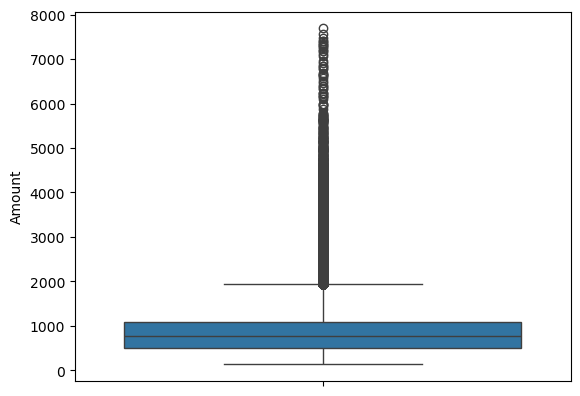

In [23]:

sns.boxplot(data=df['Amount'])

#### Conclusion :
Identified positively skewed revenue distribution with significant high-value outliers.
Observed majority of transactions concentrated between ₹500–₹1100.
Detected extreme revenue values up to ₹7500+, impacting mean and variance.


<Axes: ylabel='Quarter'>

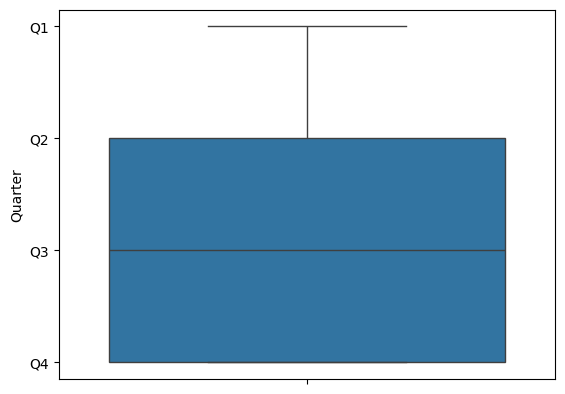

In [24]:
#sns.boxplot(x=df['Amount'])
sns.boxplot(data=df['Quarter'])

#### Conclusion : 
Analyzed quarterly distribution and observed balanced sales across all four quarters.
Identified slightly higher transaction concentration in Q3–Q4, indicating mild seasonality.
No quarter showed extreme variation or abnormal spikes.

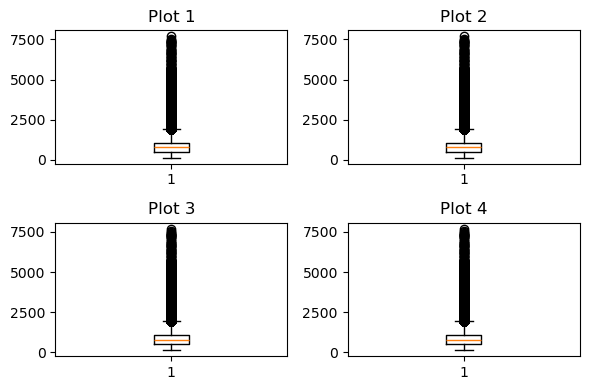

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(6,4))

ax[0,0].boxplot(df['Amount'])
ax[0,0].set_title("Plot 1")

ax[0,1].boxplot(df['Amount'])
ax[0,1].set_title("Plot 2")

ax[1,0].boxplot(df['Amount'])
ax[1,0].set_title("Plot 3")

ax[1,1].boxplot(df['Amount'])
ax[1,1].set_title("Plot 4")

plt.tight_layout()
plt.show()

#### Boxplot Analysis Conclusion:
The transaction amount distribution is highly right-skewed, indicating the presence of several high-value orders.
Majority of transactions are concentrated in the ₹500–₹1100 range, showing consistent mid-range purchasing behavior.
The median transaction value is approximately ₹750–₹800, suggesting typical customer spending falls within this range.
A significant number of extreme outliers (up to ₹7500+) were observed, representing bulk or premium purchases.
The presence of high variance and outliers suggests the need for log transformation or robust modeling techniques during predictive modeling.

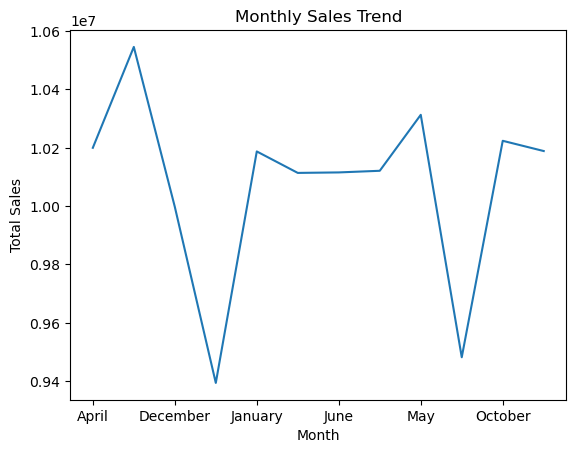

In [26]:
df.groupby('Month')['Amount'].sum().plot(kind='line')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

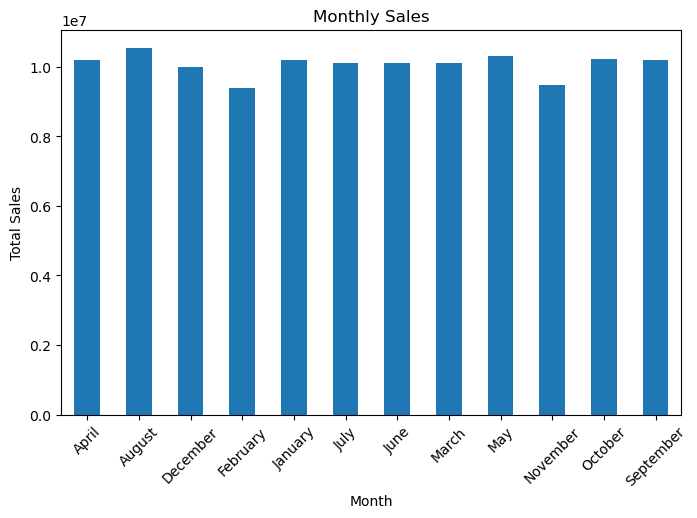

In [27]:
# Monthly Sales Analysis 
monthly_sales = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar')

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

#### Conclusion :
###### Here we can see that their no large variations in the sales . There is approximately constant sale in whole year .

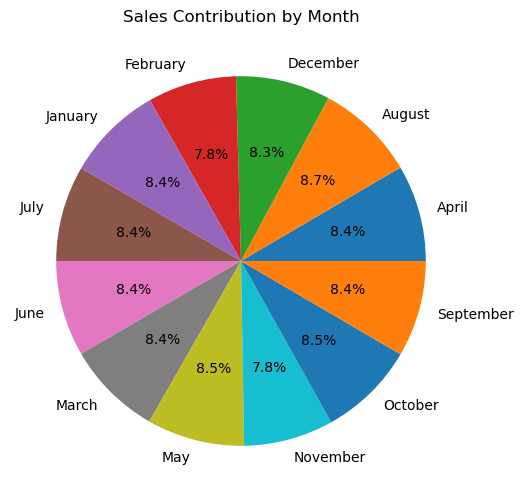

In [28]:
monthly_sales = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(6,6))
monthly_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales Contribution by Month")
plt.ylabel("")
plt.show()

#### Sales Contribution by Month –Conclusion :
Monthly sales contribution is evenly distributed throughout the year, with each month contributing approximately 7.8%–8.7% of total sales.
August (8.7%) shows the highest sales contribution, followed closely by May and October.
February (7.8%) and November (7.8%) have slightly lower contributions compared to other months.
No extreme seasonal spikes are observed, indicating stable and consistent sales performance across the year.
The balanced distribution suggests reduced dependency on a single season, improving revenue stability.

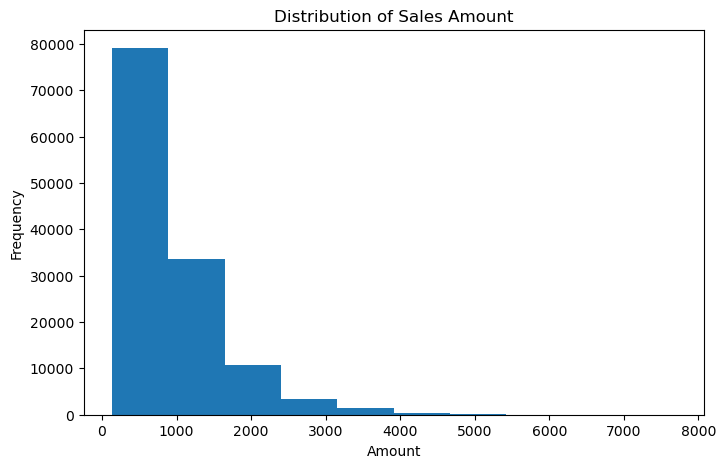

In [29]:
#Distribution of Sales Amount
plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=10)

plt.title("Distribution of Sales Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

#### Distribution of Sales Amount – Conclusion
The sales amount distribution is highly positively skewed (right-skewed).
Majority of transactions are concentrated between ₹300 and ₹1500.
Very few transactions exceed ₹3000, indicating limited high-value purchases.
The long right tail shows the presence of premium or bulk orders, but they occur infrequently.

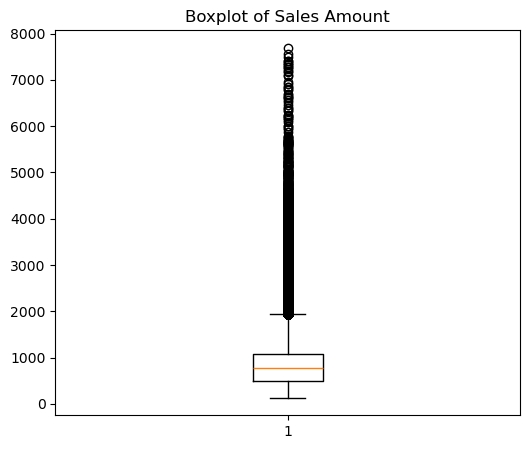

In [30]:
plt.figure(figsize=(6,5))
plt.boxplot(df['Amount'])

plt.title("Boxplot of Sales Amount")
plt.show()

#### Boxplot of Sales Amount – Conclusion 
The sales amount shows a strong positive skew, confirming the histogram findings.
The median transaction value is around ₹750–₹800.
The interquartile range (IQR) indicates most sales fall between ₹500 and ₹1100.
A large number of extreme high-value outliers (above ₹2000 up to ₹7500+) are present.
These outliers significantly increase overall variance and impact the mean sales value.
The data is non-normally distributed, making transformation (e.g., log scaling) suitable for predictive modeling.

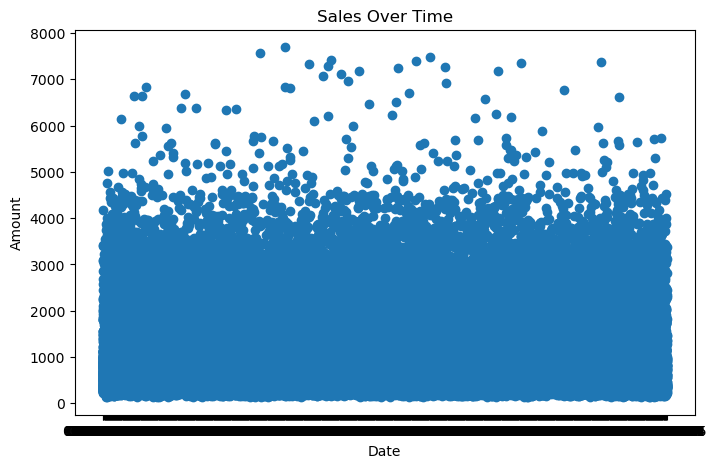

In [31]:
# Sales Over Time
plt.figure(figsize=(8,5))
plt.scatter(df['Order Date'], df['Amount'])

plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.show()

#### Conclusion :
Sales amounts are widely scattered over time with no clear upward or downward trend.
Most sales values fall roughly between 0 and 4,500.
There are occasional high-value outliers reaching around 7,500+.
The distribution suggests consistent variability in sales rather than steady growth.
Overall, sales appear stable but highly fluctuating across the period.

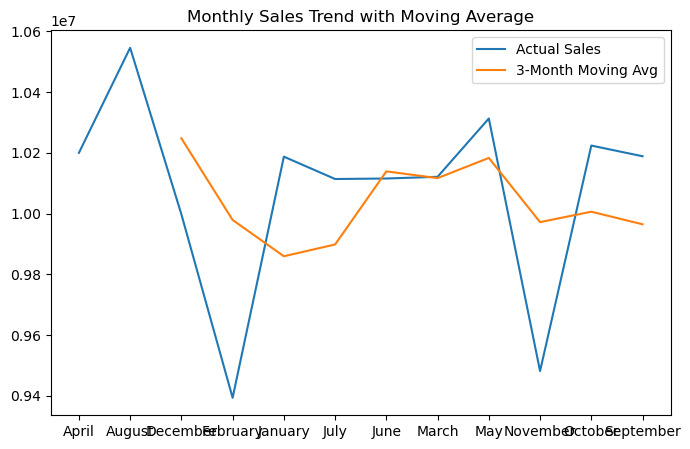

In [32]:
monthly_sales = df.groupby('Month')['Amount'].sum()

rolling_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales, label='Actual Sales')
plt.plot(rolling_avg, label='3-Month Moving Avg')

plt.legend()
plt.title("Monthly Sales Trend with Moving Average")
plt.show()

#### Conclusion :
Actual sales show noticeable month-to-month fluctuations with some sharp drops and peaks.
The 3-month moving average smooths the trend, indicating overall relatively stable performance.
There are two clear dips where sales fall significantly below surrounding months.
Peak sales months stand out but are not sustained, suggesting temporary increases.
Overall, the moving average suggests stable sales with short-term volatility rather than long-term growth or decline.

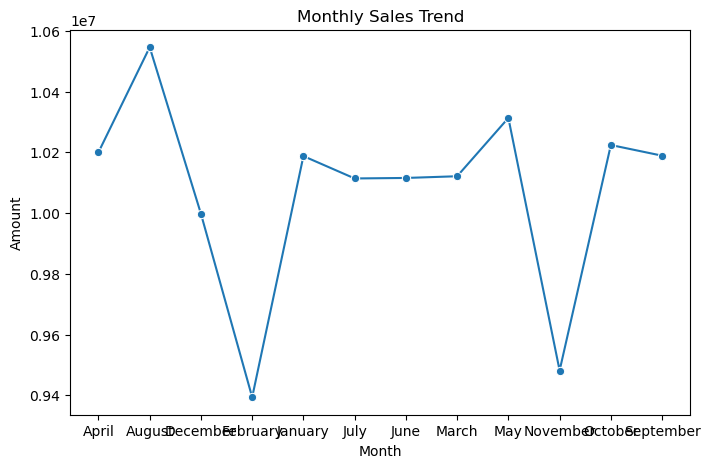

In [33]:
# Monthly Sales Trend
import seaborn as sns

monthly_sales = df.groupby('Month')['Amount'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(data=monthly_sales, x='Month', y='Amount', marker='o')

plt.title("Monthly Sales Trend")
plt.show()


#### Conclusion :
Sales fluctuate across months with no consistent upward or downward trend.
August appears to have the highest sales, while February shows the lowest.
There is a sharp drop after peak months, indicating possible seasonal or external effects.
Most months maintain sales around a similar average range (~10–10.3 million).
Overall, sales are generally stable with a few significant dips and spikes.

In [34]:
df.columns

Index(['Order ID', 'Date', 'Order Date', 'Month', 'Year', 'Quarter', 'Week',
       'Day of Week', 'Is Weekend', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'Is_Promotion', 'B2B', 'fulfilled-by'],
      dtype='object')


Monthly Time Series Created
Order Date
2024-09-01    3423743.84
2024-10-01    3435741.51
2024-11-01    3194746.95
2024-12-01    3290954.94
2025-01-01      50154.45
Name: Amount, dtype: float64

ADF Test Results:
ADF Statistic : -1.7099
p-value       : 0.4260
→ Series is Non-Stationary (Differencing Applied in SARIMA)

Training Months : 34
Testing Months  : 3


C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Model Performance:
AIC : 196.14
BIC : 195.87

Model Evaluation (Test Set):
MAE  : ₹674,577.94
RMSE : ₹730,992.38


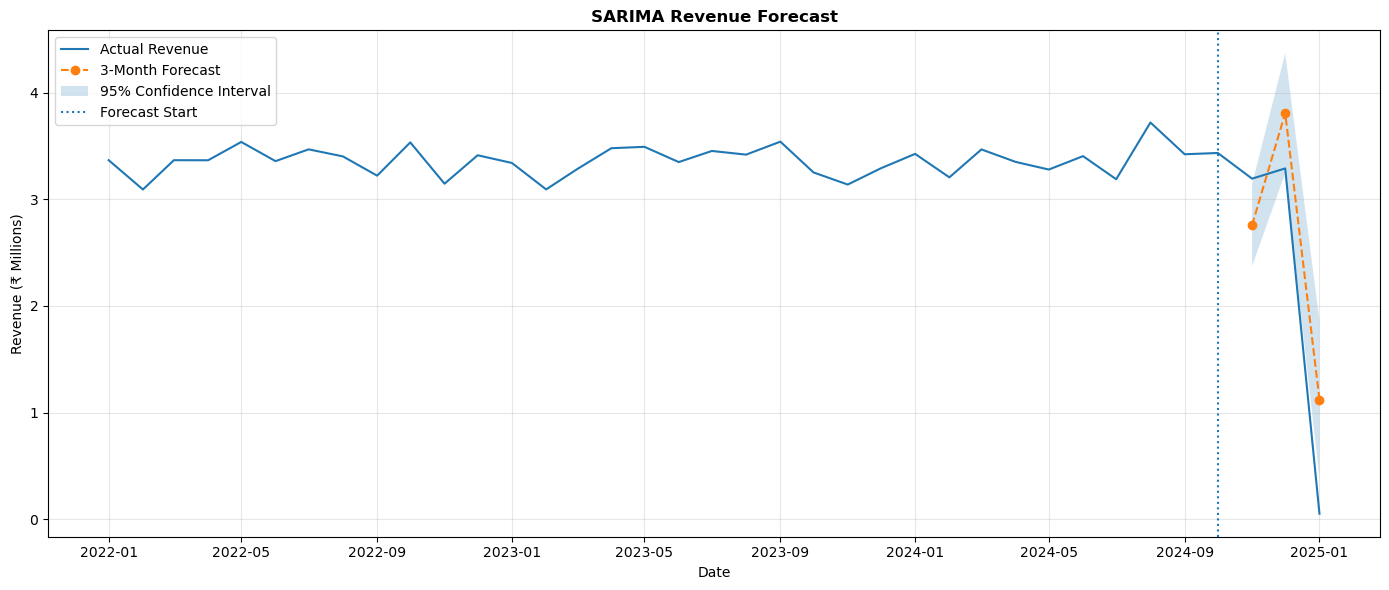


3-Month Revenue Forecast:
Nov 2024 : ₹2.76M
Dec 2024 : ₹3.81M
Jan 2025 : ₹1.12M

[SARIMA Forecast Completed Successfully]


In [35]:
# Convert Order Date column

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
# Aggregate Monthly Revenue
monthly_df = df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Amount'].sum().reset_index()

# Set index
monthly_df.set_index('Order Date', inplace=True)

monthly_ts = monthly_df['Amount']

print("\nMonthly Time Series Created")
print(monthly_ts.tail())


# Stationarity Check (ADF Test)
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_ts)

print("\nADF Test Results:")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")

if adf_result[1] < 0.05:
    print("→ Series is Stationary")
else:
    print("→ Series is Non-Stationary (Differencing Applied in SARIMA)")


# Train-Test Split (Last 3 Months Test)
train_size = len(monthly_ts) - 3
train = monthly_ts.iloc[:train_size]
test = monthly_ts.iloc[train_size:]

print(f"\nTraining Months : {len(train)}")
print(f"Testing Months  : {len(test)}")


# SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

print("\nModel Performance:")
print(f"AIC : {results.aic:.2f}")
print(f"BIC : {results.bic:.2f}")


# Forecast Next 3 Months
forecast_obj = results.get_forecast(steps=3)

forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int()

# Align forecast index
forecast_mean.index = test.index
forecast_ci.index = test.index


# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))

print("\nModel Evaluation (Test Set):")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")


# Plot Forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(monthly_ts.index, monthly_ts/1e6, label="Actual Revenue")

plt.plot(forecast_mean.index, forecast_mean/1e6,
         marker='o', linestyle='--',
         label="3-Month Forecast")

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0]/1e6,
    forecast_ci.iloc[:,1]/1e6,
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.axvline(train.index[-1], linestyle=':', label="Forecast Start")

plt.title("SARIMA Revenue Forecast", fontweight="bold")
plt.ylabel("Revenue (₹ Millions)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Print Forecast Values
print("\n3-Month Revenue Forecast:")
for date, value in forecast_mean.items():
    print(f"{date.strftime('%b %Y')} : ₹{value/1e6:.2f}M")

print("\n[SARIMA Forecast Completed Successfully]")


[ARIMA Forecasting Started]

Monthly Time Series Created
Date
2024-09-01    3423743.84
2024-10-01    3435741.51
2024-11-01    3194746.95
2024-12-01    3290954.94
2025-01-01      50154.45
Name: Amount, dtype: float64

ADF Test Results:
ADF Statistic : -1.7099
p-value       : 0.4260

Training Months : 34
Testing Months  : 3

Model Performance:
AIC : 905.01
BIC : 909.50


C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Model Evaluation (Test Set):
MAE  : ₹1,239,359.55
RMSE : ₹1,950,109.91


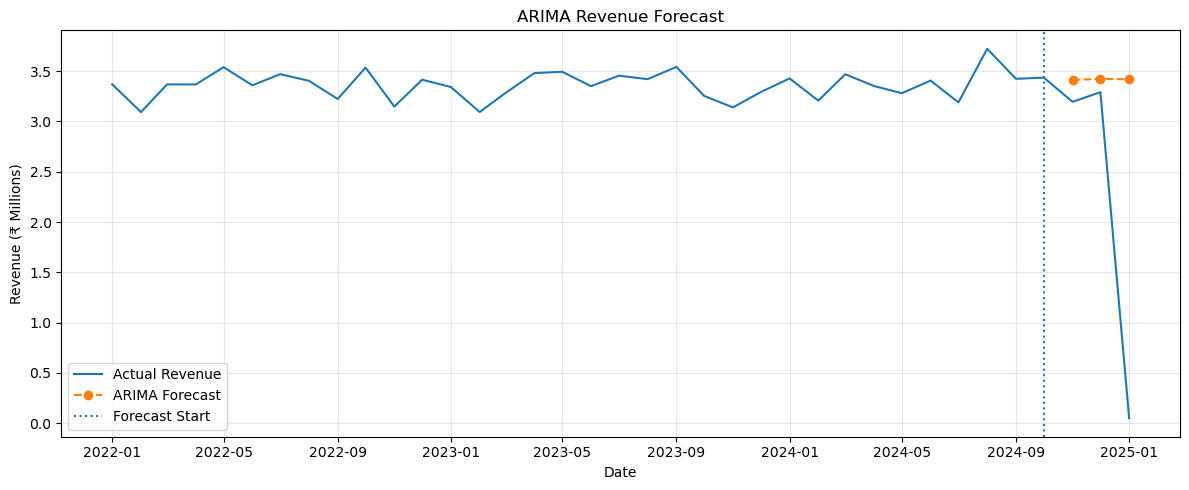


3-Month Revenue Forecast:
Nov 2024 : ₹3.41M
Dec 2024 : ₹3.42M
Jan 2025 : ₹3.42M

[ARIMA Forecast Completed Successfully]


In [36]:
# ════════════════════════════════════════════════
# PROFESSIONAL ARIMA REVENUE FORECASTING
# ════════════════════════════════════════════════

print("\n[ARIMA Forecasting Started]")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ────────────────────────────────────────────────
# 1️⃣ Prepare Monthly Time Series
# ────────────────────────────────────────────────

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate Monthly Revenue
monthly_df = df.groupby(pd.Grouper(key='Date', freq='MS'))['Amount'].sum().reset_index()

monthly_df.set_index('Date', inplace=True)

monthly_ts = monthly_df['Amount']

print("\nMonthly Time Series Created")
print(monthly_ts.tail())

# ────────────────────────────────────────────────
# 2️⃣ Stationarity Check (ADF Test)
# ────────────────────────────────────────────────

adf_result = adfuller(monthly_ts)

print("\nADF Test Results:")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")

# ────────────────────────────────────────────────
# 3️⃣ Train-Test Split (Last 3 Months Test)
# ────────────────────────────────────────────────

train_size = len(monthly_ts) - 3
train = monthly_ts.iloc[:train_size]
test = monthly_ts.iloc[train_size:]

print(f"\nTraining Months : {len(train)}")
print(f"Testing Months  : {len(test)}")

# ────────────────────────────────────────────────
# 4️⃣ ARIMA Model (p,d,q)
# ────────────────────────────────────────────────
# If non-stationary, d=1 usually works

model = ARIMA(train, order=(1,1,1))
results = model.fit()

print("\nModel Performance:")
print(f"AIC : {results.aic:.2f}")
print(f"BIC : {results.bic:.2f}")

# ────────────────────────────────────────────────
# 5️⃣ Forecast
# ────────────────────────────────────────────────

forecast = results.forecast(steps=3)
forecast.index = test.index

# ────────────────────────────────────────────────
# 6️⃣ Model Evaluation
# ────────────────────────────────────────────────

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("\nModel Evaluation (Test Set):")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")

# ────────────────────────────────────────────────
# 7️⃣ Plot Forecast
# ────────────────────────────────────────────────

plt.figure(figsize=(12,5))

plt.plot(monthly_ts.index, monthly_ts/1e6,
         label="Actual Revenue")

plt.plot(forecast.index, forecast/1e6,
         marker='o', linestyle='--',
         label="ARIMA Forecast")

plt.axvline(train.index[-1],
            linestyle=':',
            label="Forecast Start")

plt.title("ARIMA Revenue Forecast")
plt.ylabel("Revenue (₹ Millions)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# 8️⃣ Print Forecast Values
# ────────────────────────────────────────────────

print("\n3-Month Revenue Forecast:")
for date, value in forecast.items():
    print(f"{date.strftime('%b %Y')} : ₹{value/1e6:.2f}M")

print("\n[ARIMA Forecast Completed Successfully]")

C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\dell\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


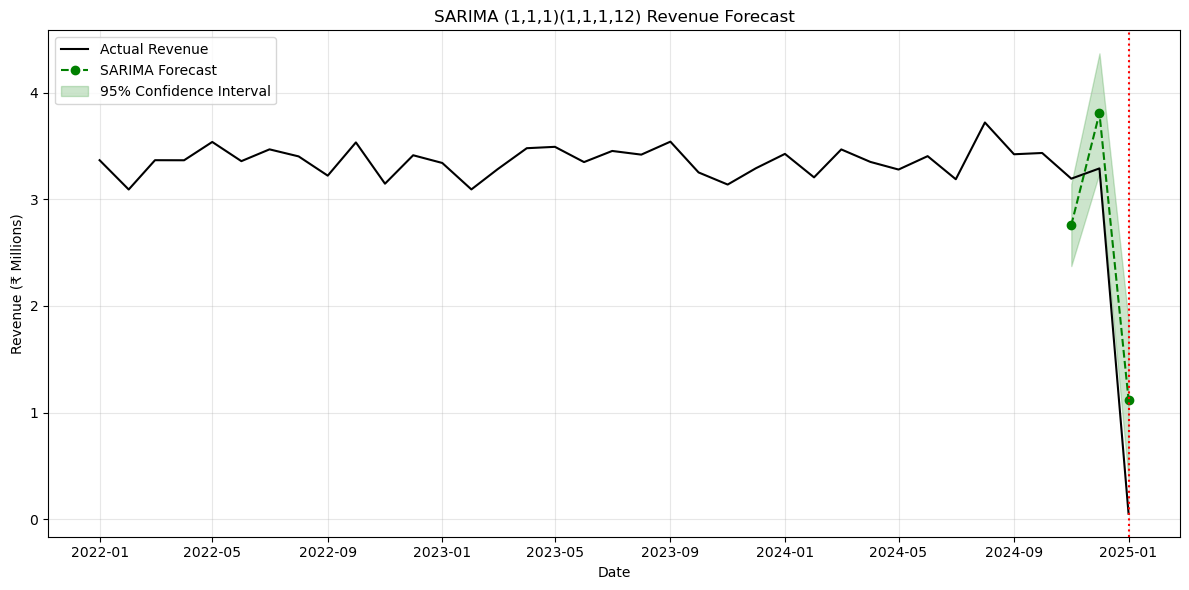

In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA (1,1,1)(1,1,1,12)
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)

# Forecast
sarima_forecast = sarima_results.get_forecast(steps=3)
sarima_mean = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

# Plot
plt.figure(figsize=(12,6))

plt.plot(monthly_ts.index, monthly_ts/1e6,
         label="Actual Revenue", color="black")

plt.plot(sarima_mean.index, sarima_mean/1e6,
         marker='o', linestyle='--',
         color='green', label="SARIMA Forecast")

plt.fill_between(sarima_ci.index,
                 sarima_ci.iloc[:,0]/1e6,
                 sarima_ci.iloc[:,1]/1e6,
                 color='green', alpha=0.2,
                 label="95% Confidence Interval")

plt.axvline(monthly_ts.index[-1], linestyle=':', color='red')

plt.title("SARIMA (1,1,1)(1,1,1,12) Revenue Forecast")
plt.ylabel("Revenue (₹ Millions)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
df.columns

Index(['Order ID', 'Date', 'Order Date', 'Month', 'Year', 'Quarter', 'Week',
       'Day of Week', 'Is Weekend', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'Is_Promotion', 'B2B', 'fulfilled-by'],
      dtype='object')

In [39]:
import pandas as pd
import numpy as np

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Rename target safely (change if needed)
df.columns = df.columns.str.strip()

target_col = df.columns[0]   # assuming revenue is only column

# Create Time Features
df['month'] = df.index.month
df['year'] = df.index.year

# Create Lag Features
df['lag_1'] = df[target_col].shift(1)
df['lag_2'] = df[target_col].shift(2)
df['lag_3'] = df[target_col].shift(3)

df = df.dropna()

df.head()

,Order ID,Order Date,Month,Year,Quarter,Week,Day of Week,Is Weekend,Status,Fulfilment,...,ship-country,promotion-ids,Is_Promotion,B2B,fulfilled-by,month,year,lag_1,lag_2,lag_3
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,405-100082-8313475,2022-01-01,January,2022,Q1,52,Saturday,True,Shipped,Amazon,...,IN,,0,True,Easy Ship,1,2022,405-100083-2483586,405-100084-9015538,405-100000-6912135
2022-01-01,405-100081-1596434,2022-01-01,January,2022,Q1,52,Saturday,True,Cancelled,Amazon,...,IN,,0,True,Easy Ship,1,2022,405-100082-8313475,405-100083-2483586,405-100084-9015538
2022-01-01,405-100079-7912587,2022-01-01,January,2022,Q1,52,Saturday,True,Cancelled,Amazon,...,IN,,0,True,Easy Ship,1,2022,405-100081-1596434,405-100082-8313475,405-100083-2483586
2022-01-01,405-100078-6063441,2022-01-01,January,2022,Q1,52,Saturday,True,Shipped,Amazon,...,IN,,0,True,Easy Ship,1,2022,405-100079-7912587,405-100081-1596434,405-100082-8313475
2022-01-01,405-100077-2334127,2022-01-01,January,2022,Q1,52,Saturday,True,Returned,Merchant,...,IN,,0,True,Merchant,1,2022,405-100078-6063441,405-100079-7912587,405-100081-1596434


In [40]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop(target_col, axis=1)
y_train = train[target_col]

X_test = test.drop(target_col, axis=1)
y_test = test[target_col]

In [41]:
target_col = 'Amount'

train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop(target_col, axis=1)
y_train = train[target_col]

X_test = test.drop(target_col, axis=1)
y_test = test[target_col]

In [42]:
import numpy as np

X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 315.36899484918376
RMSE: 433.17488775970287


# My-SQL Queries

### connect with mySQL

In [44]:
from sqlalchemy import create_engine, text
import urllib.parse

In [45]:
username   = 'root'
password   = 'Unicorn@9163'
host       = 'localhost'
port       = '3306'
database   = 'customer_behavior'

safe_password = urllib.parse.quote_plus(password)
engine = create_engine(
    f'mysql+pymysql://{username}:{safe_password}@{host}:{port}/{database}',
    pool_pre_ping=True
)

with engine.connect() as conn:
    conn.execute(text('SELECT 1'))
print('✔ Connected to MySQL successfully!')

✔ Connected to MySQL successfully!


In [46]:
df.head()

,Order ID,Order Date,Month,Year,Quarter,Week,Day of Week,Is Weekend,Status,Fulfilment,...,ship-country,promotion-ids,Is_Promotion,B2B,fulfilled-by,month,year,lag_1,lag_2,lag_3
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,405-100082-8313475,2022-01-01,January,2022,Q1,52,Saturday,True,Shipped,Amazon,...,IN,,0,True,Easy Ship,1,2022,405-100083-2483586,405-100084-9015538,405-100000-6912135
2022-01-01,405-100081-1596434,2022-01-01,January,2022,Q1,52,Saturday,True,Cancelled,Amazon,...,IN,,0,True,Easy Ship,1,2022,405-100082-8313475,405-100083-2483586,405-100084-9015538
2022-01-01,405-100079-7912587,2022-01-01,January,2022,Q1,52,Saturday,True,Cancelled,Amazon,...,IN,,0,True,Easy Ship,1,2022,405-100081-1596434,405-100082-8313475,405-100083-2483586
2022-01-01,405-100078-6063441,2022-01-01,January,2022,Q1,52,Saturday,True,Shipped,Amazon,...,IN,,0,True,Easy Ship,1,2022,405-100079-7912587,405-100081-1596434,405-100082-8313475
2022-01-01,405-100077-2334127,2022-01-01,January,2022,Q1,52,Saturday,True,Returned,Merchant,...,IN,,0,True,Merchant,1,2022,405-100078-6063441,405-100079-7912587,405-100081-1596434


In [47]:
# Load CSV (update path if needed)
df=pd.read_csv("amazon_sales_data.csv")

print(f'Rows: {len(df):,}  |  Columns: {len(df.columns)}')
print(df.dtypes)
df.head(3)

Rows: 129,000  |  Columns: 30
Order ID               object
Date                   object
Order Date             object
Month                  object
Year                    int64
Quarter                object
Week                    int64
Day of Week            object
Is Weekend               bool
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code        int64
ship-country           object
promotion-ids          object
Is_Promotion            int64
B2B                      bool
fulfilled-by           object
dtype: object


,Order ID,Date,Order Date,Month,Year,Quarter,Week,Day of Week,Is Weekend,Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,Is_Promotion,B2B,fulfilled-by
0,405-100000-6912135,2022-01-01,01-01-2022,January,2022,Q1,52,Saturday,True,Shipped,...,INR,500.91,West Bengal City,West Bengal,632664,IN,NaN,0,True,Easy Ship
1,405-100001-1748949,2022-01-01,01-01-2022,January,2022,Q1,52,Saturday,True,Shipped,...,INR,843.64,Haryana City,Haryana,665320,IN,Amazon FreeShipping|IN Core Free Shipping,1,True,Easy Ship
2,405-100002-3178930,2022-01-01,01-01-2022,January,2022,Q1,52,Saturday,True,Cancelled,...,INR,390.64,Maharashtra City,Maharashtra,858998,IN,Amazon FreeShipping|IN Core Free Shipping,1,True,Easy Ship


In [48]:
# Upload to MySQL
table_name = 'amazon_sales'

df.to_sql(
    table_name,
    con=engine,
    if_exists='replace',   # drops & recreates table each run
    index=False,
    chunksize=1000
)

print(f'✔ Table "{table_name}" created — {len(df):,} rows inserted!')

✔ Table "amazon_sales" created — 129,000 rows inserted!
